# Oracle demonstrations

Four self-contained demonstrations of the `PyBaMMOracle` digital twin:

1. **Charge rate** — how the state of health, terminal voltage and EIS respond to C-rate.
2. **Temperature sweep** — the same protocol at several ambient temperatures.
3. **SPM vs SPMe vs DFN** — the three reduced-order PyBaMM models on one protocol
   (electrolyte overpotential and cost/stiffness trade-offs).
4. **Degradation presets** — `nominal` vs `accelerated` vs `severe` over several cycles.

> **Runtime / requirements.** Runs real PyBaMM simulations, so it is **slow-ish**
> (minutes). The **core install is sufficient** — it uses the fast analytic Randles
> stub for the ECM step:
>
> ```bash
> uv sync
> ```
>
> Committed with outputs pre-rendered; not executed in CI or on the docs builder.
> DFN in §3 is the slowest model, so that section uses a single short protocol.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from battery_oracle import PyBaMMOracle, make_pybamm_candidates, OracleFailure
from battery_oracle.oracle import _randles_stub_ecm
from battery_oracle._plotting import slipstream, label_axes

plt.rcParams.update({"font.family": "serif", "figure.dpi": 120, "axes.grid": True,
                     "grid.alpha": 0.3})

def cmap_colors(n):
    return [slipstream(i / max(n - 1, 1)) for i in range(n)]


## 1. Create a PyBAMM Oracle from Config
A config is just a nested dict with the same layout as config_oracle_defaults.yml.
Any field you omit falls back to PyBaMMOracle's own default, so a "simple" config
only needs to name the knobs you care about. Here we set two groups explicitly:

```
eis.*         -> EIS measurement noise
degradation.* -> which physical ageing mechanisms are switched on
```
build_oracle_from_oracle_config() maps this dict onto PyBaMMOracle(**kwargs) and,
since no fitter lives in the config, wires up the fast analytic Randles ECM stub
(so this runs on the core install, no AutoEIS needed).

> This is the same functionality as creating an oracle_config.yml.

In [2]:
from battery_oracle import build_oracle_from_oracle_config

config = {
    "model": {"type": "SPMe"},                 # SPMe | SPM | DFN
    "cycling": {"temperature_K": 298.15},

    # --- Noise settings (synthetic potentiostat noise added to each EIS spectrum) ---
    "eis": {
        "noise_level": 0.005,                   # fractional amplitude (~.5% lab EIS noise); 0.0 disables
        "noise_model": "combined",             # "white" | "flicker" | "combined" | "none"
        "noise_combined_flicker_frac": 0.5,   # 1/f share of the "combined" budget
        "noise_combined_white_frac": 0.5,     # white share of the "combined" budget
    },

    # --- Degradation mechanisms (which ageing physics are active) ---
    "degradation": {
        "preset": "accelerated",               # nominal | accelerated | severe
        "eol_capacity_fraction": 0.80,         # OracleFailure raised once SOH < this
        # preset_constants overrides the numeric degradation constants for the named
        # preset (build_*_config reads only the entry matching `preset` above). The
        # active mechanism set is fixed per preset inside oracle.py; the boolean flags
        # below are documentation only. Here "accelerated" = SEI + lithium plating.
        "preset_constants": {
            "accelerated": {
                "sei": True,                   # (doc) solid-electrolyte-interphase growth
                "lithium_plating": True,       # (doc) Li plating (adds C-rate sensitivity)
                "particle_cracking": False,    # (doc)
                "sei_on_cracks": False,        # (doc)
                "plating_kinetic_rate_constant_m_s": 1.0e-8,   # active override
                "dead_lithium_decay_constant_s": 4.0e-6,       # active override
            },
        },
    },
}

oracle = build_oracle_from_oracle_config(config)

# Read the settings back off the constructed oracle to confirm they took effect.
print("model              :", oracle._model)
print("EIS noise          :", oracle._eis_noise_model, "@", oracle._eis_noise_level)
print("  flicker / white  :", oracle._noise_combined_flicker_frac,
      "/", oracle._noise_combined_white_frac)
print("degradation preset :", config["degradation"]["preset"])
print("active mechanisms  :", oracle._deg_opts)   # resolved SEI / plating / cracking options
print("EOL SOH fraction   :", oracle.eol_capacity_fraction)


model              : SPMe
EIS noise          : combined @ 0.005
  flicker / white  : 0.5 / 0.5
degradation preset : accelerated
active mechanisms  : {'SEI': ('ec reaction limited', 'none'), 'lithium plating': ('partially reversible', 'none')}
EOL SOH fraction   : 0.8


## 2. Charge-rate sweep

Sweep the first-stage charge current across `make_pybamm_candidates`, run one cycle
from a fresh cell at each rate, and compare SOH, end-of-charge terminal voltage, and
the post-charge EIS spectrum.


In [3]:
cands = make_pybamm_candidates(n_candidates=5)
crates = [float(c[0]) for c in cands]
soh, endV, specs = [], [], []
for proto in cands:
    o = build_oracle_from_oracle_config(config)  # fresh cell each rate, using the config above
    o.reset()
    try:
        o(proto)
    except OracleFailure as exc:
        soh.append(np.nan); endV.append(np.nan); specs.append(None); continue
    h = o._history[-1]
    soh.append(h["end_soh"])
    try:
        endV.append(float(o._prev_solution["Terminal voltage [V]"].entries[-1]))
    except Exception:
        endV.append(np.nan)
    specs.append((h["Z_charge_real"], h["Z_charge_neg_imag"]))


[PyBaMMOracle] call 0: raw_protocol=[ 68.   34.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 1.7000 A for 900 seconds or until 4.3 V', 'Charge at 0.8500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 0: raw_protocol=[ 86.   43.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 2.1500 A for 900 seconds or until 4.3 V', 'Charge at 1.0750 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 0: raw_protocol=[104.   52.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 2.6000 A for 900 seconds or until 4.3 V', 'Charge at 1.3000 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 0: raw_protocol=[122.   61.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 3.0500 A for 900 seconds or until 4.3 V', 'Charge at 1.5250 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 0: raw_protocol=[140.   70.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 3.5000 A for 900 seconds or until 4.3 V', 'Charge at 1.7500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


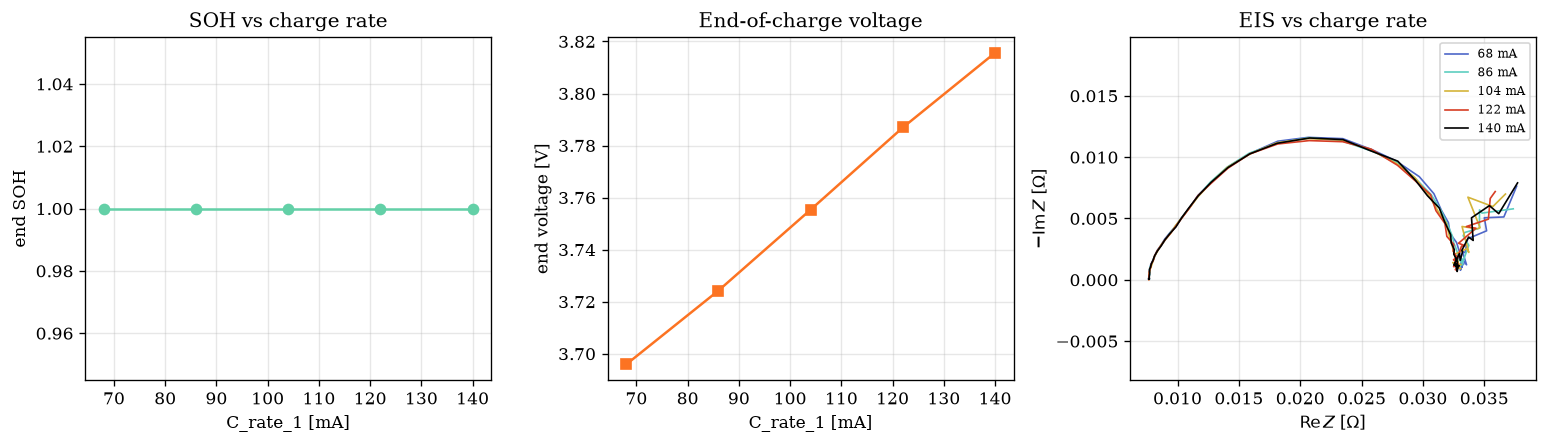

In [4]:
cols = cmap_colors(len(cands))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(crates, soh, "o-", color=slipstream(0.3)); axes[0].set_xlabel("C_rate_1 [mA]")
axes[0].set_ylabel("end SOH"); axes[0].set_title("SOH vs charge rate")
axes[1].plot(crates, endV, "s-", color=slipstream(0.6)); axes[1].set_xlabel("C_rate_1 [mA]")
axes[1].set_ylabel("end voltage [V]"); axes[1].set_title("End-of-charge voltage")
for (s, c, cr) in zip(specs, cols, crates):
    if s is not None:
        axes[2].plot(s[0], s[1], "-", color=c, lw=1, label=f"{cr:.0f} mA")
axes[2].set_xlabel(r"$\mathrm{Re}\,Z$ [$\Omega$]"); axes[2].set_ylabel(r"$-\mathrm{Im}\,Z$ [$\Omega$]")
axes[2].set_title("EIS vs charge rate"); axes[2].legend(fontsize=7); axes[2].set_aspect("equal", adjustable="datalim")
plt.tight_layout()


## 2. Temperature sweep

Construct oracles at several ambient temperatures (the `temperature_K` kwarg sets
PyBaMM's `"Ambient temperature [K]"`) and compare SOH and EIS on one protocol.


In [5]:
temps = [288.15, 298.15, 308.15, 318.15]
proto = make_pybamm_candidates(n_candidates=1)[0]
t_soh, t_specs = [], []
for T in temps:
    cfg_T = {**config, "cycling": {**config["cycling"], "temperature_K": T}}  # config above, T overridden
    o = build_oracle_from_oracle_config(cfg_T)
    o.reset()
    try:
        o(proto)
    except OracleFailure:
        t_soh.append(np.nan); t_specs.append(None); continue
    h = o._history[-1]
    t_soh.append(h["end_soh"]); t_specs.append((h["Z_charge_real"], h["Z_charge_neg_imag"]))


[PyBaMMOracle] call 0: raw_protocol=[ 68.   34.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 1.7000 A for 900 seconds or until 4.3 V', 'Charge at 0.8500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 0: raw_protocol=[ 68.   34.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 1.7000 A for 900 seconds or until 4.3 V', 'Charge at 0.8500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 0: raw_protocol=[ 68.   34.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 1.7000 A for 900 seconds or until 4.3 V', 'Charge at 0.8500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 0: raw_protocol=[ 68.   34.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 1.7000 A for 900 seconds or until 4.3 V', 'Charge at 0.8500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


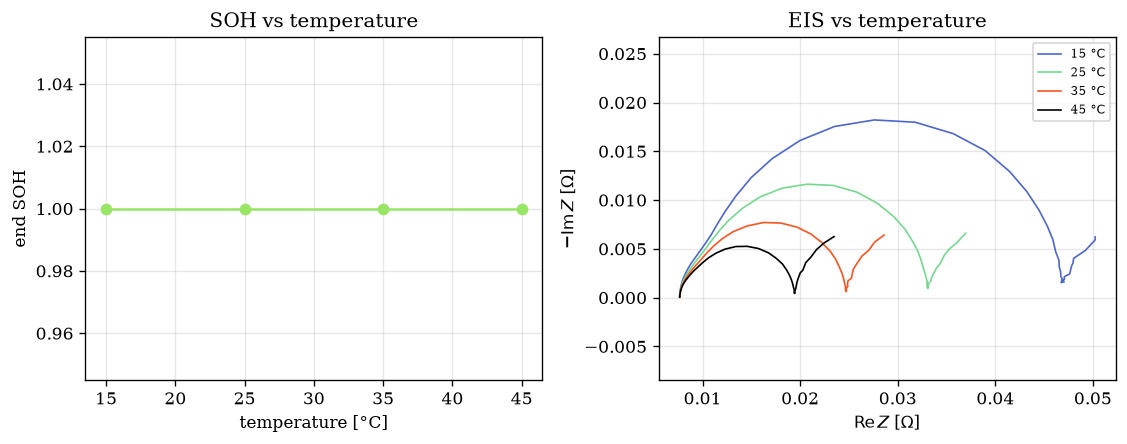

In [ ]:
cols = cmap_colors(len(temps))
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
axes[0].plot([T - 273.15 for T in temps], t_soh, "o-", color=slipstream(0.4))
axes[0].set_xlabel("temperature [°C]"); axes[0].set_ylabel("end SOH"); axes[0].set_title("SOH vs temperature")
for s, c, T in zip(t_specs, cols, temps):
    if s is not None:
        axes[1].plot(s[0], s[1], "-", color=c, lw=1, label=f"{T-273.15:.0f} °C")
axes[1].set_xlabel(r"$\mathrm{Re}\,Z$ [$\Omega$]"); axes[1].set_ylabel(r"$-\mathrm{Im}\,Z$ [$\Omega$]")
axes[1].set_title("EIS vs temperature"); axes[1].legend(fontsize=7); axes[1].set_aspect("equal", adjustable="datalim")
plt.tight_layout()


## 3. SPM vs SPMe vs DFN

The `model` kwarg selects the reduced-order PyBaMM model. **SPM** has no
electrolyte (so it misses the electrolyte overpotential), **SPMe** adds electrolyte
transport, and **DFN** is the full Doyle–Fuller–Newman model (most accurate, but the
slowest and numerically stiffest — see the numerical-stability docs). We run one
short protocol through each and overlay the terminal-voltage trace and the EIS.


In [7]:
proto = make_pybamm_candidates(n_candidates=1)[0]
model_runs = {}
for m in ("SPM", "SPMe", "DFN"):
    cfg_m = {**config, "model": {**config["model"], "type": m}}  # config above, model type overridden
    o = build_oracle_from_oracle_config(cfg_m)
    o.reset()
    try:
        o(proto)
    except OracleFailure as exc:
        print(m, "failed:", exc); model_runs[m] = None; continue
    sol = o._prev_solution
    t = np.asarray(sol["Time [s]"].entries) / 3600.0
    V = np.asarray(sol["Terminal voltage [V]"].entries)
    h = o._history[-1]
    model_runs[m] = dict(t=t, V=V, Zr=h["Z_charge_real"], nImZ=h["Z_charge_neg_imag"])


[PyBaMMOracle] call 0: raw_protocol=[ 68.   34.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 1.7000 A for 900 seconds or until 4.3 V', 'Charge at 0.8500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 0: raw_protocol=[ 68.   34.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 1.7000 A for 900 seconds or until 4.3 V', 'Charge at 0.8500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 0: raw_protocol=[ 68.   34.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 1.7000 A for 900 seconds or until 4.3 V', 'Charge at 0.8500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


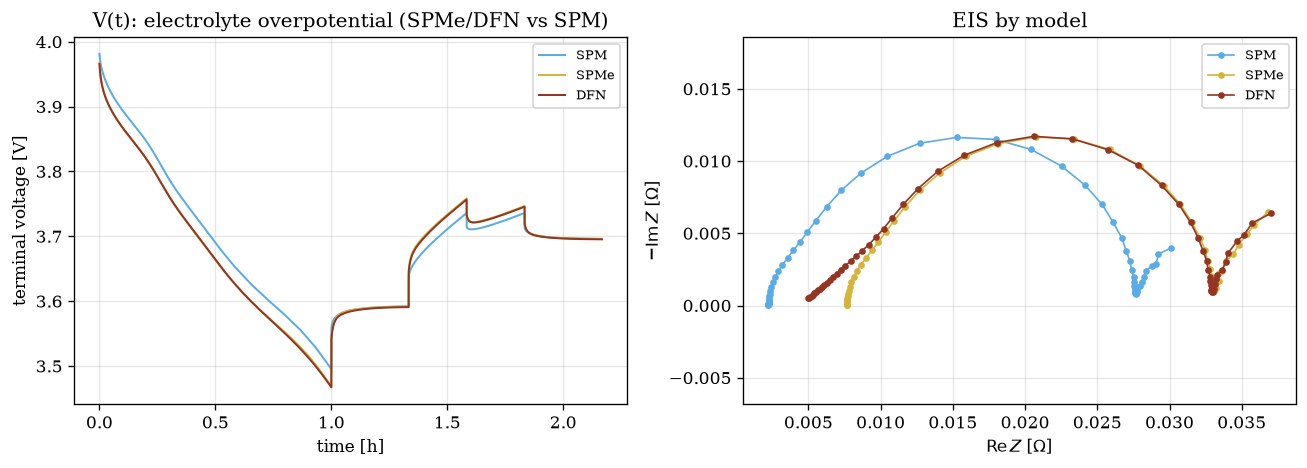

: 

In [ ]:
cols = {"SPM": slipstream(0.1), "SPMe": slipstream(0.5), "DFN": slipstream(0.85)}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for m, r in model_runs.items():
    if r is None:
        continue
    axes[0].plot(r["t"], r["V"], "-", color=cols[m], lw=1.2, label=m)
    axes[1].plot(r["Zr"], r["nImZ"], "o-", color=cols[m], ms=3, lw=1, label=m)
axes[0].set_xlabel("time [h]"); axes[0].set_ylabel("terminal voltage [V]")
axes[0].set_title("V(t): electrolyte overpotential (SPMe/DFN vs SPM)"); axes[0].legend(fontsize=8)
axes[1].set_xlabel(r"$\mathrm{Re}\,Z$ [$\Omega$]"); axes[1].set_ylabel(r"$-\mathrm{Im}\,Z$ [$\Omega$]")
axes[1].set_title("EIS by model"); axes[1].legend(fontsize=8); axes[1].set_aspect("equal", adjustable="datalim")
plt.tight_layout()


## 4. Degradation presets

`nominal` (SEI only), `accelerated` (SEI + mild lithium plating) and `severe`
(SEI + aggressive plating) are distinguished *only* by their lithium-plating
kinetics. Plating is negligible under a gentle charge, so this demo drives a **high
charge rate (~1.7C) at a cool 10 °C** over several cycles to activate it. `severe`
then pulls clearly away, while `nominal` and `accelerated` stay close — accelerated's
plating rate constant (`1e-8`) is 10× weaker than severe's (`1e-7`), too mild to
separate much from pure SEI.


In [9]:
# Lithium plating -- the ONLY mechanism that separates these presets -- only turns on
# at high charge overpotential (high C-rate, low temperature). A gentle protocol makes
# all three presets look identical, so drive a high charge rate (~1.7C: raw 340 mA x
# 25 cap_scale = 8.5 A in the 5 Ah frame) at a cool 10 degC over several cycles.
n_cycles = 12
proto = make_pybamm_candidates(n_candidates=1, c_rate_min_mA=340.0, c_rate_max_mA=340.0)[0]
preset_soh = {}
for preset in ("nominal", "accelerated", "severe"):
    # config above, but preset overridden and cycled at 10 degC to activate plating.
    # nominal/severe are absent from the config's preset_constants, so the oracle falls
    # back to its built-in defaults for those (_DEFAULT_PRESET_CONSTANTS in oracle.py).
    cfg_p = {
        **config,
        "cycling": {**config["cycling"], "temperature_K": 283.15},
        "degradation": {**config["degradation"], "preset": preset},
    }
    o = build_oracle_from_oracle_config(cfg_p)
    o.reset()
    soh = []
    for _ in range(n_cycles):
        try:
            o(proto)
        except OracleFailure:
            break
        soh.append(o._history[-1]["end_soh"])
    preset_soh[preset] = soh


[PyBaMMOracle] call 0: raw_protocol=[340.  170.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 8.5000 A for 900 seconds or until 4.3 V', 'Charge at 4.2500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 1: raw_protocol=[340.  170.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 8.5000 A for 900 seconds or until 4.3 V', 'Charge at 4.2500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 2: raw_protocol=[340.  170.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 8.5000 A for 900 seconds or until 4.3 V', 'Charge at 4.2500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 3: raw_protocol=[340.  170.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 8.5000 A for 900 seconds or until 4.3 V', 'Charge at 4.2500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 4: raw_protocol=[340.  170.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 8.5000 A for 900 seconds or until 4.3 V', 'Charge at 4.2500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


...

[PyBaMMOracle] call 7: raw_protocol=[340.  170.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 8.5000 A for 900 seconds or until 4.3 V', 'Charge at 4.2500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 8: raw_protocol=[340.  170.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 8.5000 A for 900 seconds or until 4.3 V', 'Charge at 4.2500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 9: raw_protocol=[340.  170.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 8.5000 A for 900 seconds or until 4.3 V', 'Charge at 4.2500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 10: raw_protocol=[340.  170.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 8.5000 A for 900 seconds or until 4.3 V', 'Charge at 4.2500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


[PyBaMMOracle] call 11: raw_protocol=[340.  170.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 8.5000 A for 900 seconds or until 4.3 V', 'Charge at 4.2500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


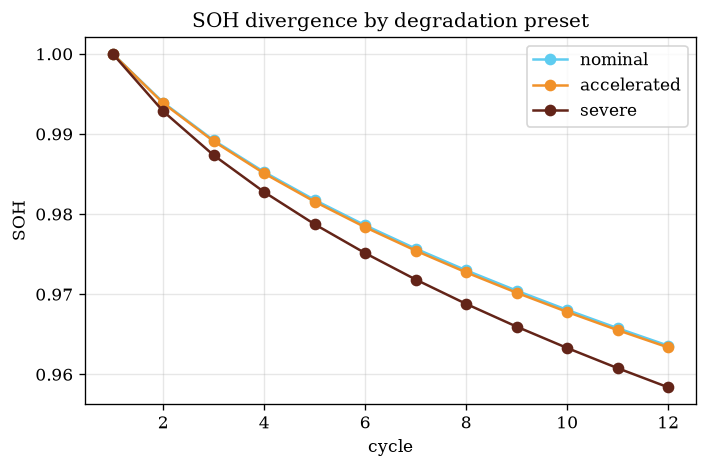

In [10]:
cols = {"nominal": slipstream(0.15), "accelerated": slipstream(0.55), "severe": slipstream(0.9)}
fig, ax = plt.subplots(figsize=(6, 4))
for preset, soh in preset_soh.items():
    ax.plot(range(1, len(soh) + 1), soh, "o-", color=cols[preset], label=preset)
ax.set_xlabel("cycle"); ax.set_ylabel("SOH"); ax.set_title("SOH divergence by degradation preset")
ax.legend()
plt.tight_layout()
